In [33]:
import pandas as pd
import numpy as np

from sksurv.ensemble import RandomSurvivalForest
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sksurv.util import Surv

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sksurv.linear_model import CoxnetSurvivalAnalysis
from lifelines import CoxPHFitter

import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_data_csv = "/content/drive/MyDrive/bachelor/train_preprocessed.csv"
else:
    nacc_data_csv = "train_preprocessed.csv"

In [24]:
train_df = pd.read_csv(nacc_data_csv)

In [42]:
train_df['EVENT_MCI'].value_counts()

EVENT_MCI
False    6307
True     1087
Name: count, dtype: int64

In [25]:
train_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
False    0.852989
True     0.147011
Name: proportion, dtype: float64

In [26]:
train_df

,continuous__TRAILB,continuous__ANIMALS,continuous__VEG,continuous__NACCAGEB,categorical__NACCNOVS_1,continuous__TRAILA,categorical__NACCNOVS_0,continuous__BPSYS,categorical__DECIN_1.0,continuous__BPDIAS,...,categorical__WHODIDDX_1.0,categorical__NACCMOM_0.0,categorical__VISION_0.0,categorical__BRNINCTE_8.0,categorical__ENERGY_0.0,categorical__TRAUMBRF_0.0,categorical__IRR_0.0,categorical__group_missing_indicator_0,EVENT_MCI,TIME
0,-0.367519,0.336966,-0.007569,-1.224021,0.0,0.696945,1.0,0.040001,0.0,-0.043882,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,False,2.412047
1,-0.665800,-0.201976,1.409354,-0.712681,0.0,-0.364104,1.0,-0.691262,1.0,-0.239753,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,False,2.795346
2,-0.321629,0.696261,0.464738,-0.508145,0.0,-0.970418,1.0,-0.972517,0.0,-0.729432,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,False,18.261465
3,-0.000403,-1.639154,-1.896801,1.025875,1.0,0.166421,0.0,-1.253772,0.0,0.445797,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,False,1.226557
4,0.320823,-0.022328,-0.479877,0.412267,0.0,-0.591472,1.0,0.827515,0.0,-0.729432,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,False,7.383984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7389,-0.872302,-1.100212,0.464738,-1.939898,0.0,-0.439893,1.0,-1.478776,0.0,-1.512917,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,False,14.546201
7390,1.055053,-1.639154,-0.952185,0.616803,0.0,1.833784,1.0,-1.253772,0.0,-1.121175,...,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,False,9.957563
7391,-0.803468,0.157319,0.700892,0.412267,0.0,0.014842,1.0,3.190056,0.0,1.327218,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,False,6.001369
7392,-0.436353,-0.381623,-0.479877,-0.303609,1.0,-1.349364,0.0,-1.310023,0.0,-0.141817,...,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,False,9.470226


In [ ]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(train_df, duration_col='TIME', event_col='EVENT_MCI')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7394 total observations, 6307 right-censored observations>
             duration col = 'TIME'
                event col = 'EVENT_MCI'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7394
number of events observed = 1087
   partial log-likelihood = -8254.60
         time fit was run = 2026-03-11 10:04:14 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                               
continuous__TRAILB                      0.14      1.15      0.02            0.09            0.19                1.10                1.21
continuous__ANIMALS                    -0.12      0.89      0.03           -0.17           -0.07                0.84                0.93
continuous__VEG                        -0.15      0.86      0.03           -0.21           -0.10                0.81                0.90
continuous__NACCAGEB                    0.21      1.23      0.03            0.15            0.26                1.16                1.30
categorical__NACCNOVS_1                 0.29      1.33      0.06            0.17            0.41                1.18                1.50
continuous__TRAILA                      0.05      1.05      0.02           -0.00            0.09                1.00                1.10
categorical__NACCNOVS_0                -0.29      0.75      0.06           -0.41           -0.17                0.67                0.84
continuous__BPSYS                       0.01      1.01      0.03           -0.04            0.06                0.96                1.06
categorical__DECIN_1.0                  0.12      1.13      0.08           -0.04            0.29                0.96                1.33
continuous__BPDIAS                     -0.02      0.98      0.02           -0.07            0.03                0.93                1.03
categorical__DECSUB_0.0                -0.14      0.87      0.07           -0.27           -0.00                0.77                1.00
continuous__NACCBMI                    -0.02      0.98      0.03           -0.08            0.03                0.92                1.03
continuous__NACCAMD                     0.01      1.01      0.03           -0.04            0.06                0.96                1.06
continuous__WEIGHT                     -0.02      0.98      0.03           -0.08            0.04                0.92                1.04
continuous__HRATE                      -0.02      0.98      0.02           -0.07            0.03                0.93                1.03
continuous__CDRSUM                      0.01      1.01      0.02           -0.04            0.05                0.96                1.06
continuous__EDUC                        0.00      1.00      0.02           -0.05            0.05                0.96                1.05
categorical__NACCBETA_0.0              -0.02      0.98      0.08           -0.18            0.13                0.84                1.14
continuous__HEIGHT                     -0.01      0.99      0.03           -0.06            0.05                0.94                1.05
categorical__NACCAHTN_0.0              -0.07      0.93      0.06           -0.19            0.05                0.83                1.05
categorical__NACCMOM_1.0               -0.01      0.99      0.06           -0.13            0.11                0.88                1.12
continuous__SMOKYRS                     0.03      1.03      0.03           -0.03            0.08                0.97                1.08
categorical__NACCDIED_1                 0.04      1.05      0.09           -0.13            0.22                0.88                1.24
categorical__HYPERCHO_0.0              -0.02      0.98      0.06           -0.13            0.10                0.88                1.11
categori

In [ ]:
n_boot = 300
coefs = []

for i in range(n_boot):
    sample = train_df.sample(frac=1, replace=True)
    cph_boot = CoxPHFitter(penalizer=0.1)
    cph_boot.fit(sample, duration_col="TIME", event_col="EVENT_MCI")
    coefs.append(cph_boot.params_)

coefs_df = pd.DataFrame(coefs)

ci_lower = coefs_df.quantile(0.025)
ci_upper = coefs_df.quantile(0.975)

,coef,CI_lower,CI_upper
covariate,,,
continuous__TRAILB,0.139195,0.107867,0.173989
continuous__ANIMALS,-0.119768,-0.154921,-0.086399
continuous__VEG,-0.154650,-0.188677,-0.117451
continuous__NACCAGEB,0.206170,0.173086,0.242422
categorical__NACCNOVS_1,0.287049,0.237518,0.333288
...,...,...,...
categorical__BRNINCTE_8.0,0.051873,0.029377,0.075506
categorical__ENERGY_0.0,-0.024214,-0.089741,0.057498
categorical__TRAUMBRF_0.0,-0.029340,-0.089876,0.035104


In [40]:
coef_df = pd.DataFrame({
    "coef": cph.params_,
    "CI_lower": ci_lower,
    "CI_upper": ci_upper
})
coef_df["CI_width"] = coef_df["CI_upper"] - coef_df["CI_lower"]
coef_df.sort_values("CI_width", ascending=False)

,coef,CI_lower,CI_upper,CI_width
covariate,,,,
categorical__JUDGMENT_0.0,-0.118279,-0.297692,0.047793,0.345485
categorical__COGMODE_1.0,0.103089,-0.046143,0.244757,0.290900
categorical__IMPNOMCI_1,0.348975,0.234377,0.489254,0.254877
categorical__NACCNREX_0.0,0.118723,0.009027,0.255742,0.246715
categorical__ANX_0.0,-0.163798,-0.284368,-0.038073,0.246295
...,...,...,...,...
continuous__WEIGHT,-0.021110,-0.045376,0.004967,0.050343
categorical__FTLDEVAL_0.0,0.051928,0.026316,0.075087,0.048771
categorical__BRNINCTE_8.0,0.051873,0.029377,0.075506,0.046129


In [ ]:
coef_to_plot = coef_df.head(20)

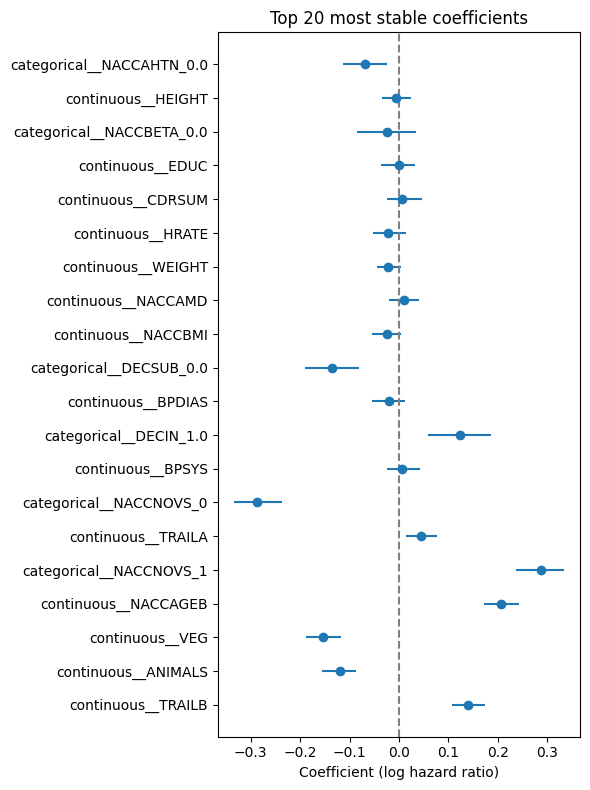

In [39]:
plt.figure(figsize=(6,8))

plt.errorbar(
    coef_to_plot["coef"],
    coef_to_plot.index,
    xerr=[
        coef_to_plot["coef"] - coef_to_plot["CI_lower"],
        coef_to_plot["CI_upper"] - coef_to_plot["coef"]
    ],
    fmt="o"
)

plt.axvline(0, linestyle="--", color="gray")
plt.xlabel("Coefficient (log hazard ratio)")
plt.title("Top 20 most stable coefficients")

plt.tight_layout()
plt.show()

In [ ]:
X_train = train_df.drop(columns=['TIME', 'EVENT_MCI'])
y_train = Surv.from_dataframe('EVENT_MCI', 'TIME', train_df)

In [ ]:
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', 0.3],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [15, 25, 50]
}

rsf = RandomSurvivalForest(random_state=42, n_jobs=-1)

best_rsf = RandomSurvivalForest(
    n_estimators=200,
    max_features='sqrt',
    min_samples_split=20,
    min_samples_leaf=25,
    random_state=42,
    n_jobs=-1
)
best_rsf.fit(X_train, y_train)

# Оценка на тесте
print(f"Test C-index: {best_rsf.score(X_test, y_test):.3f}")